# GPT-2 + Vision (Stackformer V3) — CLIP + Flamingo-style Perceiver Resampler & Gated Cross-Attention

This notebook implements **Version 3 (V3)** of **GPT2VL**, built on top of the V2 pipeline. It keeps V2's numerically-stable, on-the-fly, resumable training engine and swaps in a research-grounded vision-language bridge.

### What changed vs. V2

| Area | V2 | V3 |
|---|---|---|
| Vision encoder | Frozen `torchvision` ViT-B/16 (ImageNet-1k) | Frozen **CLIP** ViT-B/16 (`openai/clip-vit-base-patch16`), language-aligned features |
| Vision→text bridge | Perceiver Resampler (64 latents, depth 2) + gated cross-attn (raw scalar gate) | Perceiver Resampler (64 latents, depth **4**) + **tanh-gated** cross-attn (Flamingo/Llama 3.2 style) |
| Cross-attn placement | After GPT-2 layers `[3, 6, 9]` (every 3) | After GPT-2 layers `[3, 7, 11]` (every ~4, Llama-3.2-Vision spacing) |
| Dataset | `Trickxter/COCO2017-captions` — 1 caption/image | `AKCIT/coco2017-captioning` — **5 captions/image** |
| Caption handling | Single caption per image | Expanded to 5 (image, caption) training pairs; all 5 used as references for held-out BLEU/METEOR |
| Hyperparameters | Reasonable defaults | Every vision-language hyperparameter researched against Flamingo & Llama 3.2 Vision and justified (§2) |

Everything else — the `Stackformer` text backbone (`masks.py`, `attention_engine.py`, `Normalization.py`), the FP32-stable norm layers, the NaN-safe training loop, and the resumable `CheckpointManager` — is reused **unmodified** from the already-fixed `Stackformer` package. This notebook does not patch or duplicate those files; it only imports them.

**Note on module placement:** V2 already defined `GatedSparseCrossAttnBlock`, `PerceiverResamplerSF`, and the vision encoder wrapper *inline in the notebook* rather than as separate `stackformer/modules/` files — they were never part of the "already fixed" package. V3 continues that pattern for the new `CLIPVisionEncoder`, the tanh-gated cross-attn block, and the (unchanged-shape) resampler. If you'd like these promoted into `stackformer/modules/vision/` as real package modules, say the word and I'll split them out — just let me know the exact path you want them in.

In [20]:
# Install dependencies cleanly into Colab environment
!pip install -q --no-deps datasets pycocoevalcap safetensors transformers nltk
!git clone https://github.com/stackformer-labs/Stackformer.git || true
# NOTE: Stackformer's masks.py / attention_engine.py / Normalization.py are treated as
# already fixed upstream in the repo above -- V3 does not patch them locally (unlike V2).

fatal: destination path 'Stackformer' already exists and is not an empty directory.


In [21]:
import os
import sys

# Dynamically insert Stackformer repo directory into sys.path
for sf_path in ["./Stackformer", "/content/Stackformer"]:
    if os.path.exists(sf_path) and os.path.abspath(sf_path) not in sys.path:
        sys.path.insert(0, os.path.abspath(sf_path))

!pip install -q --no-deps -e ./Stackformer

import time
from tqdm.auto import tqdm
import math
import re
import json
import random
import unicodedata
import glob
import shutil
from typing import Optional, Dict, List, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

from torchvision import transforms

from datasets import load_dataset
from transformers import (
    GPT2TokenizerFast,
    GPT2LMHeadModel,
    CLIPVisionModel,
    CLIPImageProcessor,
)
from PIL import Image as PILImage
from safetensors.torch import save_file, load_file

import stackformer.modules.Attention as sf_attn
import stackformer.modules.attention_engine as sf_engine
from stackformer.modules.Attention import Cross_MultiHead_Attention
from stackformer.modules.Normalization import LayerNormalization
from stackformer.modules.Feed_forward import FF_GELU
from stackformer.models.gpt import GPT_2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for stackformer (pyproject.toml) ... done
device: cuda
GPU: Tesla T4


In [22]:
# Mount Google Drive EARLY (before CFG / model / checkpoint loading).
# This matters for RESUMING: CheckpointManager.load() runs inside
# GPT2VLTrainer.__init__ (cell '9. Data Loaders & Launch Training'), which
# happens well before the old drive.mount() cell further down. If Drive
# isn't mounted yet at that point, gdrive_checkpoint_dir simply doesn't
# exist on a fresh runtime, the epoch-1 checkpoint saved there is invisible,
# and training silently restarts from scratch instead of resuming.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ModuleNotFoundError:
    print("Not running in Colab -- skipping Google Drive mount (local checkpoints only).")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Research-Driven Hyperparameter Selection

Before writing the architecture, every vision-language tunable below was checked against three primary references:

- **Flamingo** — Alayrac et al., 2022, *"Flamingo: a Visual Language Model for Few-Shot Learning"*
- **Perceiver / Perceiver IO** — Jaegle et al., 2021, the general iterative-attention resampling mechanism Flamingo's resampler is built on
- **Llama 3.2 Vision** — Meta's 2024 multimodal Llama technical report / model card, the modern production-scale descendant of the Flamingo recipe

### Perceiver Resampler

| Parameter | Reference value(s) | V3 choice | Why |
|---|---|---|---|
| Learned latent queries | **64** in Flamingo's main config (paper and every faithful reproduction: `flamingo-mini`, `lucidrains/flamingo-pytorch`) | **64** | Directly adopted — it's the one number every reproduction agrees on, and it matches V2 so the rest of the GPT-2 stack (`context_length`, batch sizing) needs no rework. |
| Resampler depth | Reported values diverge: some analyses cite **2** layers, `flamingo-mini`'s config (closely mirroring the paper) uses **6** | **4** | A middle ground. This project trains on COCO-scale data (~590K expanded pairs) on a single T4, not the ~2B-pair Flamingo corpus — 6 layers of cross-attention run *every training step* (unlike the frozen CLIP tower) and would meaningfully slow iteration for a dataset this size, while 2 felt undersized once we're also compressing CLIP's 197 patch tokens rather than ViT's smaller grid. |
| Resampler heads | 8 (Flamingo default; `flamingo-mini`/`lucidrains` default `heads=8, dim_head=64`) | **8** | Adopted as-is; with `embed_dim=768` this gives a head dim of 96, close enough to the reference 64 that no architectural change was needed. |
| Resampler FFN expansion | `ff_mult=4` in the standard reproductions | **4×** | Adopted as-is (matches `FF_GELU`'s usual 4× hidden-dim convention already used by GPT-2 itself). |

### Gated cross-attention

| Parameter | Reference value(s) | V3 choice | Why |
|---|---|---|---|
| Placement / frequency | Flamingo: every 1 or every 2 LM layers (smaller LMs use denser insertion). Llama 3.2 Vision: cross-attention **every 4th** self-attention layer across its 40-layer decoder, reported to lose only ~1.9% performance vs. every-layer insertion while cutting training compute ~66%. | **Every ~4th layer**: `[3, 7, 11]` (0-indexed) on GPT-2's 12 layers | GPT-2-small is far smaller than Flamingo's or Llama's frozen LMs, so a *denser* schedule than Llama's every-4 would be defensible — but this project's dataset (COCO captions only, no interleaved few-shot data) doesn't need the same expressive density Flamingo targets. Every-4-ish spacing follows the Llama 3.2 precedent, which is the more directly comparable "single-image captioning" production recipe, and keeps 3 trainable cross-attn blocks — cheap enough for a T4. |
| Gate function | Both papers: `tanh(α)` scaling on the cross-attention (and, in Llama's vision-encoder extra layers, the FFN) output | **`tanh(α)`** | V2 used a raw (unbounded) scalar gate; V3 switches to the actual Flamingo/Llama mechanism — `tanh` keeps the gate in `[-1, 1]` by construction, so training can never blow up the residual stream via an ever-growing gate the way an unbounded scalar theoretically could. |
| Gate initialization | Flamingo: `α = 0` (exact identity at init). Llama 3.2's extra vision-encoder layers: `α = π/4` (~40% contribution at init) — but note Llama's *decoder* cross-attention layers are **not** gated at all. | **`α = 0`** (Flamingo-style) | We're gating a genuinely new decoder pathway (like Flamingo, not like Llama's ungated decoder xattn), so the safety property that matters is "GPT-2's pretrained behavior is exactly preserved at step 0." Zero-init is the only choice that guarantees that; `π/4` is Meta's choice for a different sub-component (extra frozen-encoder layers) and doesn't apply here. |
| Gate granularity | Both: per cross-attention-layer scalar (not per-head) | **Per-layer scalar** | Matches both references and keeps parameter count negligible; per-head gating isn't reported to help enough in either paper to justify the extra complexity here. |
| Cross-attn heads | Not separately tuned in either paper (reuses LM head count) | **12** (= GPT-2's own head count) | Simplest choice with no extra hyperparameter to justify, and avoids adding a projection just to change head count. |

### CLIP vision encoder

| Parameter | Reference value(s) | V3 choice | Why |
|---|---|---|---|
| Variant / resolution | Flamingo used a custom NFNet, not CLIP; Llama 3.2 uses a heavily modified CLIP ViT-H/14 at 448px with 8 extra encoder layers. Standard CLIP-for-captioning literature more commonly uses ViT-B/32 or ViT-B/16 at 224px. | **`openai/clip-vit-base-patch16`, 224px** | Both CLIP base variants (`patch32`, `patch16`) already output `hidden_size=768` — matching GPT-2's `embed_dim` exactly, so **no extra projection layer is needed either way**. That removes resolution as a "which is cheaper" question and leaves it as "which is more informative": `patch16` gives a 14×14=196-patch grid vs. `patch32`'s 7×7=49, i.e. 4× finer spatial detail for the Resampler to compress from. Since the vision tower is frozen (no backward pass through it), that extra detail is nearly free — the only added cost is one extra frozen forward pass per image, negligible next to the trainable cross-attention/resampler compute. |
| Freeze vs. fine-tune | Both papers freeze the vision backbone entirely | **Fully frozen** | Directly adopted. CLIP's features are already language-aligned by contrastive pretraining, and COCO (even at 5×-expanded ~590K pairs) is small enough that fine-tuning a 90M-parameter ViT risks catastrophic forgetting of that alignment for no clear benefit, exactly the failure mode both papers freeze to avoid. |
| Feature layer | CLIP-for-captioning papers differ: some use the final pre-pooling `last_hidden_state` (all patch tokens), others an earlier/penultimate layer to preserve localization that the final contrastive-projection layer partially discards. | **`last_hidden_state`** (all patch + CLS tokens, pre-projection, pre-pooling) | We never touch CLIP's `pooled_output`/text-projection head at all — that pooled embedding is optimized for image-level contrastive matching, not per-patch spatial detail. `last_hidden_state` keeps full per-patch resolution for the Resampler to attend over, which is what a captioning model (needing "what is where," not just "what is this image of") actually wants. |

### Training / optimization

| Parameter | Reference value(s) | V3 choice | Why |
|---|---|---|---|
| Learning rate | Papers train only the new modules with the (frozen) backbones untouched, at a standard AdamW LR in the `1e-4`–`3e-4` range for the scale of new params here | **`1e-4`**, single LR for all trainable params | Unchanged from V2. Only `resampler` + `cross_blocks` are trainable (backbones frozen, as above) — there's no separate frozen/pretrained group requiring a *different* LR the way full fine-tuning setups need, so a single LR for the single trainable group is the correct match for this design, not an under-tuned default. |
| Warmup | Standard practice for training new attention modules from scratch | **5% linear warmup** (`OneCycleLR`, unchanged from V2) | Kept — nothing about swapping ViT→CLIP or the dataset changes the argument for warming up newly-initialized attention weights. |
| Batch size | N/A (dataset-size dependent) | **32**, `grad_accum_steps=2` (effective 64), unchanged from V2 | Kept — GPU memory budget (T4) didn't change; CLIP-B/16 and ViT-B/16 are comparable in forward-pass cost. |
| Epochs | N/A | **3** (down from V2's 10) | Task 2 expands the dataset 5× (one training pair per caption instead of per image). 3 epochs over the 5×-expanded set gives the model ~the same *total number of (image, caption) gradient steps* as V2's ~10 epochs over the 1×-caption set, while exposing it to 5× more caption phrasings per image rather than repeating the same sentence 10 times — a better use of the same compute budget. |
| Cross-attn dropout | Both papers apply standard dropout inside the new blocks | **0.1** (= `cfg["dropout"]`, unchanged) | Kept; no paper-specific override justified. |

**Bottom line:** every value above is either a direct adoption of a paper/reproduction default, or a documented deviation driven by this project's actual constraints (single T4, ~590K expanded COCO pairs, frozen backbones) rather than by blindly copying billion-pair-scale numbers.

In [23]:
CFG = {
    # Dataset & Storage
    "dataset_name": "AKCIT/coco2017-captioning",
    "checkpoint_dir": "./gpt2vl_v3_checkpoints_res",
    "gdrive_checkpoint_dir": "/content/drive/MyDrive/gpt2vl_v3_checkpoints",


    # GPT-2 Small Backbone (unchanged from V2)
    "vocab_size": 50258,
    "embed_dim": 768,
    "num_layers": 12,
    "num_heads": 12,
    "hidden_dim": 3072,
    "context_length": 128,
    "dropout": 0.1,
    "qkv_bias": True,

    # --- Task 1: CLIP vision encoder -----------------------------------
    "clip_model_name": "openai/clip-vit-base-patch16",  # see \u00a72: finer patch grid, frozen so nearly free
    "vision_dim": 768,             # CLIP ViT-B hidden size == GPT-2 embed_dim -> no projection needed
    "freeze_vision_encoder": True,

    # --- Task 1: Perceiver Resampler (Flamingo-style) -------------------
    "num_visual_tokens": 64,       # latent queries (Flamingo default)
    "perceiver_depth": 3,          # compromise between 2 (lucidrains) and 6 (flamingo-mini) refs; see \u00a72
    "perceiver_heads": 8,
    "perceiver_hidden_mult": 4,    # FFN expansion ratio inside resampler blocks

    # --- Task 1: Gated cross-attention (tanh-gated, zero-init) ---------
    "cross_attention_pos": [3, 7, 11],   # every ~4th GPT-2 layer (Llama-3.2-Vision spacing)
    "cross_attention_heads": 12,          # reuse GPT-2's own head count
    "gate_init": 0.0,                     # Flamingo-style zero-init -> tanh(0) = 0 = full pass-through
    "alpha_clamp": 4.0,                   # keep alpha within tanh's responsive region (|x|>~3 saturates)

    # Training Setup & Scheduler
    "batch_size": 32,
    "grad_accum_steps": 2,      # Effective batch size = 64
    "learning_rate": 1e-4,
    "min_learning_rate": 1e-6,
    "warmup_pct": 0.05,         # 5% warmup steps
    "weight_decay": 0.01,
    "num_epochs": 3,            # dataset is 5x larger (Task 2) -> fewer epochs, see \u00a72
    "max_grad_norm": 1.0,       # Gradient clipping norm to prevent FP16 overflow
    # "time_budget_minutes" removed -- the time-limit auto-stop was removed from the trainer
    "amp_dtype": "fp16" if torch.cuda.is_available() else "fp32",

    # --- Task 2: dataset / multi-caption handling -----------------------
    "eval_holdout_images": 1000,   # held-out IMAGES (each carries up to 5 reference captions)
    "eval_seed": 42,
}
print(CFG)

{'dataset_name': 'AKCIT/coco2017-captioning', 'checkpoint_dir': './gpt2vl_v3_checkpoints_res', 'gdrive_checkpoint_dir': '/content/drive/MyDrive/gpt2vl_v3_checkpoints', 'vocab_size': 50258, 'embed_dim': 768, 'num_layers': 12, 'num_heads': 12, 'hidden_dim': 3072, 'context_length': 128, 'dropout': 0.1, 'qkv_bias': True, 'clip_model_name': 'openai/clip-vit-base-patch16', 'vision_dim': 768, 'freeze_vision_encoder': True, 'num_visual_tokens': 64, 'perceiver_depth': 3, 'perceiver_heads': 8, 'perceiver_hidden_mult': 4, 'cross_attention_pos': [3, 7, 11], 'cross_attention_heads': 12, 'gate_init': 0.0, 'alpha_clamp': 4.0, 'batch_size': 32, 'grad_accum_steps': 2, 'learning_rate': 0.0001, 'min_learning_rate': 1e-06, 'warmup_pct': 0.05, 'weight_decay': 0.01, 'num_epochs': 3, 'max_grad_norm': 1.0, 'amp_dtype': 'fp16', 'eval_holdout_images': 1000, 'eval_seed': 42}


## 4. Model Architecture — CLIP + Flamingo-style Perceiver Resampler + Tanh-Gated Cross-Attention

Three building blocks, wired into `GPT2VL`:

1. **`CLIPVisionEncoder`** — replaces V2's `TorchvisionViTEncoder`. Frozen CLIP ViT-B/16, returns `last_hidden_state` patch tokens.
2. **`PerceiverResamplerSF`** — same shape as V2 (kept, since it already matches the Flamingo mechanism), now driven by the researched `perceiver_depth`/`perceiver_heads`.
3. **`GatedSparseCrossAttnBlock`** — upgraded from V2's raw-scalar gate to a proper **`tanh(\u03b1)`** gate, zero-initialized.

In [24]:
class CLIPVisionEncoder(nn.Module):
    '''Frozen pretrained CLIP ViT patch-token extractor for on-the-fly execution.

    Uses `last_hidden_state` (all patch tokens + CLS, pre-pooling, pre-projection) so the
    Perceiver Resampler gets full spatial detail rather than a single pooled embedding
    -- see \u00a72 ("Feature layer") for the reasoning.
    '''

    def __init__(self, model_name="openai/clip-vit-base-patch16", freeze=True):
        super().__init__()
        self.model = CLIPVisionModel.from_pretrained(model_name)
        self.hidden_dim = self.model.config.hidden_size
        self.freeze = freeze
        if freeze:
            for p in self.model.parameters():
                p.requires_grad = False
            self.model.eval()

    def train(self, mode: bool = True):
        # Keep the frozen CLIP tower in eval() regardless of the outer model's mode,
        # so its (unused, since frozen) dropout/layernorm running stats never drift.
        super().train(mode)
        if self.freeze:
            self.model.eval()
        return self

    def forward(self, pixel_values):
        if self.freeze:
            with torch.no_grad():
                out = self.model(pixel_values=pixel_values)
        else:
            out = self.model(pixel_values=pixel_values)
        return out.last_hidden_state  # (B, num_patches + 1, hidden_dim)


def _extract_edge_size(size_field) -> int:
    if isinstance(size_field, int):
        return size_field
    for key in ("height", "shortest_edge", "width"):
        try:
            val = size_field[key]
        except (KeyError, TypeError, IndexError):
            continue
        if isinstance(val, int):
            return val
    for key in ("height", "shortest_edge", "width"):
        val = getattr(size_field, key, None)
        if isinstance(val, int):
            return val
    raise ValueError(f"Could not determine an integer edge size from {size_field!r}")


def build_clip_image_transform(clip_model_name: str):
    proc = CLIPImageProcessor.from_pretrained(clip_model_name)
    crop_field = proc.crop_size if proc.crop_size is not None else proc.size
    size = _extract_edge_size(crop_field)
    mean, std = proc.image_mean, proc.image_std
    return transforms.Compose([
        transforms.Resize((size, size)),
        transforms.Lambda(lambda im: im.convert("RGB") if hasattr(im, "convert") else im),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])

In [25]:
class PerceiverResamplerSF(nn.Module):
    '''Compresses a sequence of vision-encoder patch tokens down to fixed `num_latents` tokens
    via iterative cross-attention using stackformer primitives. Unchanged in shape from V2 --
    only `depth`/`heads` are now driven by the researched CFG values (see \u00a72).'''

    def __init__(self, embed_dim, num_latents, depth, num_heads, dropout=0.0, hidden_dim=None,
                 device="cpu", dtype=torch.float32):
        super().__init__()
        hidden_dim = hidden_dim or embed_dim * 4  # Task 3: ff_mult=4, see \u00a72
        self.latents = nn.Parameter(torch.randn(num_latents, embed_dim, device=device, dtype=dtype) * 0.02)
        self.cross_layers = nn.ModuleList([
            Cross_MultiHead_Attention(embed_dim, num_heads, dropout=dropout, qkv_bias=True, device=device, dtype=dtype)
            for _ in range(depth)
        ])
        self.norm_latent = nn.ModuleList([LayerNormalization(embed_dim, device=device, dtype=dtype) for _ in range(depth)])
        self.norm_media = nn.ModuleList([LayerNormalization(embed_dim, device=device, dtype=dtype) for _ in range(depth)])
        self.ffns = nn.ModuleList([FF_GELU(embed_dim, hidden_dim, dropout, device=device, dtype=dtype) for _ in range(depth)])
        self.ffn_norms = nn.ModuleList([LayerNormalization(embed_dim, device=device, dtype=dtype) for _ in range(depth)])
        self.depth = depth

    def forward(self, media_seq):
        b = media_seq.shape[0]
        x = self.latents.unsqueeze(0).expand(b, -1, -1)
        for i in range(self.depth):
            xn = self.norm_latent[i](x)
            ctx = self.norm_media[i](media_seq)
            x = x + self.cross_layers[i](xn, ctx, mask=False)
            x = x + self.ffns[i](self.ffn_norms[i](x))
        return x

In [26]:
class GatedSparseCrossAttnBlock(nn.Module):
    '''Pre-norm residual gated cross-attention block: GPT-2 hidden states attend to the
    (compressed) visual tokens through a **tanh(alpha)** gate, alpha zero-initialized
    (Flamingo/Llama-3.2 style -- see \u00a72). This is the one behavioral change from V2, which
    used a raw unbounded scalar gate instead of tanh(alpha).'''

    def __init__(self, embed_dim, num_heads, dropout, qkv_bias=True, gate_init=0.0,
                 device="cpu", dtype=torch.float32):
        super().__init__()
        self.norm = LayerNormalization(embed_dim, device=device, dtype=dtype)
        self.cross_attn = Cross_MultiHead_Attention(
            embed_dim, num_heads, dropout=dropout, qkv_bias=qkv_bias, device=device, dtype=dtype
        )
        self.drop = nn.Dropout(dropout)
        self.alpha = nn.Parameter(torch.full((1,), float(gate_init), device=device, dtype=dtype))

    def gate(self):
        return torch.tanh(self.alpha)

    def forward(self, x, context):
        residual = x
        x_norm = self.norm(x)
        attn_out = self.cross_attn(x_norm, context, mask=False)
        attn_out = self.drop(attn_out)
        return residual + self.gate() * attn_out

In [27]:
class GPT2VL(nn.Module):
    '''GPT-2 (stackformer) + frozen CLIP vision encoder + Perceiver resampler (stackformer)
    + tanh-gated sparse cross-attention (stackformer), spliced into the GPT-2 stack at
    `cross_attention_pos`.'''

    def __init__(self, cfg, device="cpu", dtype=torch.float32):
        super().__init__()
        self.cfg = cfg
        self.gpt2 = GPT_2(
            vocab_size=cfg["vocab_size"], num_layers=cfg["num_layers"], embed_dim=cfg["embed_dim"],
            num_heads=cfg["num_heads"], seq_len=cfg["context_length"], dropout=cfg["dropout"],
            hidden_dim=cfg["hidden_dim"], qkv_bias=cfg["qkv_bias"], device=device, dtype=dtype,
        )
        self.cross_attention_pos = set(cfg["cross_attention_pos"])
        self.cross_blocks = nn.ModuleDict({
            str(i): GatedSparseCrossAttnBlock(
                cfg["embed_dim"], cfg["cross_attention_heads"], cfg["dropout"], cfg["qkv_bias"],
                gate_init=cfg["gate_init"], device=device, dtype=dtype,
            )
            for i in cfg["cross_attention_pos"]
        })
        self.vision_encoder = CLIPVisionEncoder(
            model_name=cfg["clip_model_name"], freeze=cfg["freeze_vision_encoder"]
        )
        assert self.vision_encoder.hidden_dim == cfg["vision_dim"], (
            f"CLIP hidden size {self.vision_encoder.hidden_dim} != cfg['vision_dim'] {cfg['vision_dim']}"
        )
        self.resampler = PerceiverResamplerSF(
            cfg["embed_dim"], cfg["num_visual_tokens"], cfg["perceiver_depth"], cfg["perceiver_heads"],
            cfg["dropout"], hidden_dim=cfg["embed_dim"] * cfg["perceiver_hidden_mult"],
            device=device, dtype=dtype,
        )

    def encode_image(self, images):
        patch_tokens = self.vision_encoder(images)  # (B, N_patches+1, vision_dim)
        patch_tokens = patch_tokens.to(dtype=self.resampler.latents.dtype)
        return self.resampler(patch_tokens)  # (B, num_visual_tokens, embed_dim)

    def forward(self, input_ids, images=None, visual_context=None):
        if visual_context is None and images is not None:
            visual_context = self.encode_image(images)

        emb = self.gpt2.embedding(input_ids)
        pos = self.gpt2.position_embedding(input_ids)
        x = emb + pos

        layers = getattr(self.gpt2, 'backbone', getattr(self.gpt2, 'decoder', None)).layers
        for i, layer in enumerate(layers):
            x = layer(x, mask=True)
            if i in self.cross_attention_pos and visual_context is not None:
                x = self.cross_blocks[str(i)](x, visual_context)

        final_norm = getattr(self.gpt2, 'backbone', getattr(self.gpt2, 'decoder', None)).final_norm
        x = final_norm(x)
        return self.gpt2.lm_head(x)

    def freeze_text_backbone(self):
        for p in self.gpt2.parameters():
            p.requires_grad = False
        for p in self.vision_encoder.parameters():
            p.requires_grad = False

    def trainable_parameters(self):
        return (p for p in self.parameters() if p.requires_grad)

## 5. Text Cleaning & On-The-Fly Multi-Caption Dataset — `AKCIT/coco2017-captioning`

**Task 2 design decision.** `AKCIT/coco2017-captioning` stores **5 captions per image** as a list, unlike V2's `Trickxter/COCO2017-captions` (1 caption/image). Three strategies were possible:

1. Expand into 5 (image, caption) training pairs per image.
2. Randomly sample 1 caption per epoch.
3. Use all 5 only for validation/diversity metrics (e.g. multi-reference BLEU/METEOR).

**Chosen: (1) + (3) combined** — expand every image into 5 independent training pairs (so the *training* set sees 5x more (image, caption) examples, each a different phrasing of the same image — free caption-level augmentation, reducing overfitting to one reference's exact wording), **and** keep all 5 captions as multi-reference ground truth for the held-out evaluation split (this matches the standard COCO captioning evaluation protocol, where BLEU/METEOR/CIDEr are computed against multiple references per image, not one).

Strategy (2) (random-sample-per-epoch) was rejected because it's strictly a subset of what (1) already achieves — with 3 epochs (\u00a72) over the 5x-expanded set, the model already sees each caption roughly once anyway, without the added bookkeeping of re-sampling every epoch.

`CocoMultiCapDataset` implements both modes (`mode="train"` / `mode="eval"`) over a *single* shared `datasets.Dataset` instance, so the underlying HF dataset is only loaded once.

In [28]:
class CocoMultiCapDataset(Dataset):
    '''Dataset over a shared HF `datasets.Dataset` instance (see \u00a75 above).

    mode="train": expands `row_indices` into one item per (image, caption) pair -- Task 2
                  strategy (1). len() == 5x len(row_indices) (assuming 5 captions/image).
    mode="eval":  one item per image row; `raw_captions` returns ALL captions for that image
                  (multi-reference eval -- Task 2 strategy (3)); `input_ids`/`labels` are still
                  built from a single (first) caption so teacher-forced eval_loss stays well-defined.
    '''

    IMAGE_FIELD_CANDIDATES = ("image", "img")
    CAPTION_FIELD_CANDIDATES = ("captions", "caption", "sentences", "sentences_raw", "text")

    def __init__(self, hf_dataset, tokenizer, context_length, row_indices, mode="train",
                 image_transform=None):
        assert mode in ("train", "eval")
        self.ds = hf_dataset
        self.mode = mode
        self.tok = tokenizer
        self.ctx = context_length
        self.transform = image_transform

        cols = set(self.ds.column_names)
        self.image_field = next((c for c in self.IMAGE_FIELD_CANDIDATES if c in cols), None)
        self.caption_field = next((c for c in self.CAPTION_FIELD_CANDIDATES if c in cols), None)
        if self.image_field is None or self.caption_field is None:
            raise ValueError(
                f"Could not find image/caption columns in dataset columns={sorted(cols)}. "
                f"Tried image candidates={self.IMAGE_FIELD_CANDIDATES}, "
                f"caption candidates={self.CAPTION_FIELD_CANDIDATES}. "
                f"Update CocoMultiCapDataset.*_FIELD_CANDIDATES to match the actual schema."
            )

        self.bos_id = tokenizer.bos_token_id or tokenizer.eos_token_id
        self.eos_id = tokenizer.eos_token_id

        # PERF FIX: pull the whole captions column ONCE via columnar access
        # (self.ds[self.caption_field]) instead of self.ds[row_idx] per row.
        # Row-wise access returns the FULL row -- including decoding the JPEG
        # image -- just to read 5 caption strings. Over ~118K rows that decode
        # cost is the multi-minute stall between "Raw dataset: ... images"
        # printing and training actually starting. Column access reads only
        # the caption strings and is essentially instant. Cached per
        # underlying hf_dataset so building both the train and eval splits
        # only pays this cost once.
        self._captions_col = self._get_cached_captions_column()

        self.row_indices = list(row_indices)
        if mode == "train":
            # Expand: one entry per (row_idx, caption_idx) -- Task 2 strategy (1)
            self.index = []
            for row_idx in self.row_indices:
                n_caps = len(self._raw_captions(row_idx))
                for cap_idx in range(n_caps):
                    self.index.append((row_idx, cap_idx))
        else:
            # One entry per image row -- Task 2 strategy (3)
            self.index = list(self.row_indices)

    _CAPTIONS_COLUMN_CACHE = {}  # {(id(hf_dataset), caption_field): List[caption-lists]}

    def _get_cached_captions_column(self):
        key = (id(self.ds), self.caption_field)
        cache = CocoMultiCapDataset._CAPTIONS_COLUMN_CACHE
        if key not in cache:
            # Columnar read: fast, does NOT touch/decode the image column.
            cache[key] = self.ds[self.caption_field]
        return cache[key]

    @staticmethod
    def clean_caption(text: str) -> str:
        '''Normalize unicode, remove non-printable/invalid characters, collapse whitespace, and strip.'''
        if not isinstance(text, str):
            return ""
        text = unicodedata.normalize("NFKD", text)
        text = re.sub(r'[\x00-\x1f\x7f-\x9f]', '', text)  # remove control characters
        text = re.sub(r'\s+', ' ', text)                  # collapse repeated whitespace
        return text.strip()

    def _raw_captions(self, row_idx) -> List[str]:
        raw = self._captions_col[row_idx]  # cached column lookup, no dataset row/image fetch
        if isinstance(raw, list):
            caps = [self.clean_caption(c) for c in raw if isinstance(c, str) and c.strip()]
        elif isinstance(raw, str):
            caps = [self.clean_caption(raw)]
        else:
            caps = []
        return caps if caps else ["a photo"]

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        if self.mode == "train":
            row_idx, cap_idx = self.index[idx]
            caps = self._raw_captions(row_idx)
            cap = caps[cap_idx % len(caps)]
            raw_captions = [cap]                 # single-ref during training (unused for loss)
        else:
            row_idx = self.index[idx]
            caps = self._raw_captions(row_idx)
            cap = caps[0]                        # teacher-forced eval_loss target
            raw_captions = caps                  # ALL captions -> multi-reference BLEU/METEOR

        item = self.ds[row_idx]
        img = item.get(self.image_field)
        if img is None:
            img = PILImage.new("RGB", (224, 224), color="black")

        t_img = self.transform(img)
        ids = [self.bos_id] + self.tok.encode(cap, add_special_tokens=False) + [self.eos_id]
        ids = ids[: self.ctx]
        return {
            "input_ids": torch.tensor(ids, dtype=torch.long),
            "image": t_img,
            "idx": row_idx,
            "raw_captions": raw_captions,
        }

    @staticmethod
    def collate_fn(batch, pad_id, ctx, vocab_size):
        images = torch.stack([b["image"] for b in batch], dim=0)
        indices = torch.tensor([b.get("idx", -1) for b in batch], dtype=torch.long)
        raw_captions = [b.get("raw_captions", [""]) for b in batch]  # List[List[str]], len 1 (train) or 5 (eval)

        def pad_to_ctx(seq):
            if seq.numel() >= ctx:
                s = seq[:ctx]
            else:
                s = torch.cat([seq, torch.full((ctx - seq.numel(),), pad_id, dtype=seq.dtype)])
            return torch.clamp(s, 0, vocab_size - 1)

        input_ids = torch.stack([pad_to_ctx(b["input_ids"]) for b in batch])
        labels = input_ids.clone()
        labels[:, :-1] = input_ids[:, 1:]
        labels[:, -1] = pad_id
        labels[labels == pad_id] = -100
        return {"input_ids": input_ids, "labels": labels, "images": images, "indices": indices,
                "raw_captions": raw_captions}

## 6. CheckpointManager — OO State Persistence & Auto-Sync

Unchanged from V2. It only ever persists `resampler.*` and `cross_blocks.*` (the trainable parameters), so it works as-is regardless of the vision-encoder/gate change underneath.

In [29]:
class CheckpointManager:
    '''Object-oriented manager for saving and restoring model parameters, optimizer,
    scheduler, mixed precision scaler state, and random RNG seeds across Colab sessions.'''

    def __init__(self, checkpoint_dir: str, gdrive_checkpoint_dir: Optional[str] = None):
        self.checkpoint_dir = checkpoint_dir
        self.gdrive_checkpoint_dir = gdrive_checkpoint_dir
        self.safetensors_path = os.path.join(checkpoint_dir, "model_trainable.safetensors")
        self.meta_path = os.path.join(checkpoint_dir, "checkpoint_state.pt")

    def save(self, model, optimizer, scheduler, scaler, epoch: int, step: int, loss_history: list, cfg: dict, eval_history: list = None):
        os.makedirs(self.checkpoint_dir, exist_ok=True)

        # Save trainable parameters in safetensors format
        trainable_state = {
            k: v.cpu().contiguous() for k, v in model.state_dict().items()
            if any(k.startswith(p) for p in ["resampler", "cross_blocks"])
        }
        save_file(trainable_state, self.safetensors_path)

        # Save complete metadata, optimizer, scheduler, scaler, and random RNG states
        torch.save({
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict() if scheduler else None,
            "scaler": scaler.state_dict() if scaler else None,
            "epoch": epoch,
            "step": step,
            "loss_history": loss_history,
            "eval_history": eval_history or [],
            "alpha_values": {k: v.alpha.item() for k, v in model.cross_blocks.items()},
            "rng_torch": torch.get_rng_state(),
            "rng_cuda": torch.cuda.get_rng_state() if torch.cuda.is_available() else None,
            "rng_python": random.getstate(),
            "rng_numpy": np.random.get_state(),
        }, self.meta_path)

        print(f"Saved checkpoint locally to {self.checkpoint_dir} (Epoch {epoch}, Step {step})")
        self.sync_to_gdrive()

    def sync_to_gdrive(self):
        if self.gdrive_checkpoint_dir and os.path.exists(os.path.dirname(self.gdrive_checkpoint_dir)):
            try:
                os.makedirs(self.gdrive_checkpoint_dir, exist_ok=True)
                shutil.copy(self.safetensors_path, os.path.join(self.gdrive_checkpoint_dir, "model_trainable.safetensors"))
                shutil.copy(self.meta_path, os.path.join(self.gdrive_checkpoint_dir, "checkpoint_state.pt"))
                print(f"Synced checkpoint to Google Drive: {self.gdrive_checkpoint_dir}")
            except Exception as e:
                print(f"Warning: Google Drive sync failed: {e}")

    def load(self, model, optimizer=None, scheduler=None, scaler=None) -> Tuple[int, int, list, list]:
        # If local checkpoint missing, check Google Drive
        if not os.path.exists(self.safetensors_path) and self.gdrive_checkpoint_dir and os.path.exists(os.path.join(self.gdrive_checkpoint_dir, "model_trainable.safetensors")):
            os.makedirs(self.checkpoint_dir, exist_ok=True)
            try:
                shutil.copy(os.path.join(self.gdrive_checkpoint_dir, "model_trainable.safetensors"), self.safetensors_path)
                if os.path.exists(os.path.join(self.gdrive_checkpoint_dir, "checkpoint_state.pt")):
                    shutil.copy(os.path.join(self.gdrive_checkpoint_dir, "checkpoint_state.pt"), self.meta_path)
                print(f"Restored checkpoint files from Google Drive ({self.gdrive_checkpoint_dir})")
            except Exception as e:
                print(f"Warning: Failed copying from Google Drive: {e}")

        if os.path.exists(self.safetensors_path):
            print(f"Loading trainable weights from {self.safetensors_path}...")
            state_dict = load_file(self.safetensors_path)
            model.load_state_dict(state_dict, strict=False)

            if os.path.exists(self.meta_path):
                meta = torch.load(self.meta_path, weights_only=False)
                if optimizer and meta.get("optimizer"):
                    optimizer.load_state_dict(meta["optimizer"])
                if scheduler and meta.get("scheduler"):
                    scheduler.load_state_dict(meta["scheduler"])
                if scaler and meta.get("scaler"):
                    scaler.load_state_dict(meta["scaler"])
                if meta.get("rng_torch") is not None:
                    torch.set_rng_state(meta["rng_torch"])
                if meta.get("rng_cuda") is not None and torch.cuda.is_available():
                    torch.cuda.set_rng_state(meta["rng_cuda"])
                if meta.get("rng_python") is not None:
                    random.setstate(meta["rng_python"])
                if meta.get("rng_numpy") is not None:
                    np.random.set_state(meta["rng_numpy"])

                res_epoch = meta.get("epoch", 0)
                res_step = meta.get("step", 0)
                res_loss = meta.get("loss_history", [])
                res_eval = meta.get("eval_history", [])
                print(f"Resumed seamlessly from Epoch {res_epoch}, Step {res_step}")
                return res_epoch, res_step, res_loss, res_eval
        return 0, 0, [], []

## 6b. CaptionEvaluator (moved before trainer for use in eval loop)

Unchanged from V2 -- it already accepts `references: List[List[str]]`, i.e. it already supported multi-reference scoring. V2 just always passed lists of length 1; V3's eval split now passes the full 5 references per image (Task 2), which this class handles with no code changes.

In [30]:
# CaptionEvaluator -- defined here so it is available to GPT2VLTrainer above.
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('punkt', quiet=True)

class CaptionEvaluator:
    '''BLEU-1..4 and METEOR evaluator for image captions. Supports multi-reference scoring
    (references[i] is a list of 1-5 ground-truth captions for hypothesis i).'''

    def __init__(self):
        self.smooth = SmoothingFunction().method1

    def evaluate(self, references: List[List[str]], hypotheses: List[str]) -> Dict[str, float]:
        bleu1, bleu2, bleu3, bleu4, meteor_scores = [], [], [], [], []
        for refs, hyp in zip(references, hypotheses):
            ref_tokens = [r.split() for r in refs]
            hyp_tokens = hyp.split()
            bleu1.append(sentence_bleu(ref_tokens, hyp_tokens, weights=(1,0,0,0),       smoothing_function=self.smooth))
            bleu2.append(sentence_bleu(ref_tokens, hyp_tokens, weights=(.5,.5,0,0),     smoothing_function=self.smooth))
            bleu3.append(sentence_bleu(ref_tokens, hyp_tokens, weights=(.33,.33,.33,0),  smoothing_function=self.smooth))
            bleu4.append(sentence_bleu(ref_tokens, hyp_tokens, weights=(.25,.25,.25,.25),smoothing_function=self.smooth))
            meteor_scores.append(meteor_score(ref_tokens, hyp_tokens))
        return {
            "BLEU-1": float(np.mean(bleu1)),
            "BLEU-2": float(np.mean(bleu2)),
            "BLEU-3": float(np.mean(bleu3)),
            "BLEU-4": float(np.mean(bleu4)),
            "METEOR": float(np.mean(meteor_scores)),
        }

print("CaptionEvaluator ready.")

CaptionEvaluator ready.


## 7. GPT2VLTrainer — OO Training Engine (NaN-Stable)

Unchanged from V2 except: (a) the alpha diagnostics/postfix now report `tanh(alpha)` — the *actual* gate value applied to the residual stream — alongside the raw `alpha`, and (b) `raw_captions` in a batch is now always `List[List[str]]` (1 ref during training, up to 5 during eval), matching the dataset above.

In [31]:
class GPT2VLTrainer:
    '''Trainer with tqdm progress bar, scaler-scale monitoring, first-NaN diagnostics,
    end-of-epoch evaluation (eval_loss + BLEU/METEOR on held-out set), and exact
    batch fast-forward on checkpoint resume.'''

    def __init__(self, model, train_loader, eval_loader, optimizer, scheduler, scaler,
                 loss_fn, ckpt_manager, device, cfg, tokenizer, caption_evaluator=None):
        self.model = model
        self.train_loader = train_loader
        self.eval_loader = eval_loader
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.scaler = scaler
        self.loss_fn = loss_fn
        self.ckpt_manager = ckpt_manager
        self.device = device
        self.cfg = cfg
        self.tokenizer = tokenizer
        self.caption_evaluator = caption_evaluator or CaptionEvaluator()

        self.grad_accum_steps = cfg["grad_accum_steps"]
        self.max_grad_norm = cfg.get("max_grad_norm", 1.0)
        self.alpha_clamp = cfg.get("alpha_clamp", 4.0)
        self.amp_dtype = torch.float16 if cfg["amp_dtype"] == "fp16" else torch.float32
        self._nan_dumped = False  # only emit the diagnostic dump once

        # Load checkpoint if available
        self.start_epoch, self.start_step, self.loss_history, self.eval_history = \
            self.ckpt_manager.load(self.model, self.optimizer, self.scheduler, self.scaler)

    # ------------------------------------------------------------------
    # End-of-epoch evaluation
    # ------------------------------------------------------------------
    def _eval_epoch(self, epoch_num: int) -> dict:
        '''Teacher-forced eval loss + greedy-decoded BLEU/METEOR (multi-reference) on eval_loader.'''
        if self.eval_loader is None:
            return {}

        self.model.eval()
        total_loss, n_batches = 0.0, 0
        all_refs, all_hyps = [], []
        tok = self.tokenizer
        eos_id = tok.eos_token_id
        bos_id = tok.bos_token_id if tok.bos_token_id is not None else tok.eos_token_id
        ctx = self.cfg["context_length"]

        with torch.no_grad():
            for batch in self.eval_loader:
                input_ids = batch["input_ids"].to(self.device, non_blocking=True)
                labels    = batch["labels"].to(self.device, non_blocking=True)
                images    = batch["images"].to(self.device, non_blocking=True)
                raw_caps  = batch.get("raw_captions", None)   # List[List[str]], up to 5 refs/image

                # Teacher-forced eval loss
                with torch.amp.autocast(device_type=self.device.type, dtype=self.amp_dtype):
                    logits = self.model(input_ids, images=images)
                    loss   = self.loss_fn(logits.view(-1, logits.size(-1)), labels.view(-1))
                if torch.isfinite(loss):
                    total_loss += loss.item()
                    n_batches  += 1

                # Greedy caption generation (encode image once, decode autoregressively)
                visual_ctx = self.model.encode_image(images)  # (B, num_visual_tokens, C)
                B = images.size(0)
                gen_ids = torch.full((B, 1), bos_id, dtype=torch.long, device=self.device)
                for _ in range(min(ctx - 1, 60)):   # cap at 60 new tokens for speed
                    with torch.amp.autocast(device_type=self.device.type, dtype=self.amp_dtype):
                        gen_logits = self.model(gen_ids, visual_context=visual_ctx)
                    next_tok = gen_logits[:, -1, :].argmax(dim=-1, keepdim=True)
                    gen_ids = torch.cat([gen_ids, next_tok], dim=1)
                    if (next_tok == eos_id).all():
                        break

                for b in range(B):
                    ids_b = gen_ids[b, 1:].tolist()
                    if eos_id in ids_b:
                        ids_b = ids_b[:ids_b.index(eos_id)]
                    hyp = tok.decode(ids_b, skip_special_tokens=True)
                    all_hyps.append(hyp)
                    if raw_caps is not None:
                        all_refs.append(raw_caps[b])  # already List[str] (up to 5 refs)
                    else:
                        lbl = labels[b].tolist()
                        ref_ids = [t for t in lbl if t != -100]
                        all_refs.append([tok.decode(ref_ids, skip_special_tokens=True)])

        self.model.train()

        eval_loss = total_loss / max(n_batches, 1)
        metrics = {"eval_loss": eval_loss}
        if all_refs and all_hyps:
            metrics.update(self.caption_evaluator.evaluate(all_refs, all_hyps))
        return metrics

    # ------------------------------------------------------------------
    # Training loop
    # ------------------------------------------------------------------
    def train(self):
        self.model.train()
        start_time = time.time()
        step = self.start_step
        running_loss, running_count = 0.0, 0
        self.optimizer.zero_grad(set_to_none=True)

        n_batches_total = len(self.train_loader)
        initial_epoch = self.start_epoch

        # ---- Print what's recorded in the checkpoint before resuming ----
        tqdm.write("=" * 64)
        tqdm.write(f"Resuming from checkpoint: last completed epoch = {initial_epoch}, step = {step}")
        if self.loss_history:
            tqdm.write(f"Loss history so far (avg every 20 opt steps): {self.loss_history}")
            tqdm.write(f"Most recent recorded train loss: {self.loss_history[-1]:.4f}")
        else:
            tqdm.write("No loss history found in checkpoint.")
        if self.eval_history:
            for rec in self.eval_history:
                parts = [f"{k} {v:.4f}" if isinstance(v, float) else f"{k} {v}" for k, v in rec.items()]
                tqdm.write(f"Eval metrics: {' | '.join(parts)}")
        else:
            tqdm.write("No eval history found in checkpoint.")
        tqdm.write("=" * 64)

        tqdm.write(f"Starting training: Epoch {initial_epoch + 1}/{self.cfg['num_epochs']}, Step {step}")
        tqdm.write("(Resuming at the start of this epoch -- no mid-epoch batch fast-forwarding, and no time-limit stop.)")

        for epoch in range(initial_epoch, self.cfg["num_epochs"]):

            pbar = tqdm(
                self.train_loader,
                desc=f"Epoch {epoch+1}/{self.cfg['num_epochs']}",
                total=n_batches_total,
                dynamic_ncols=True,
            )

            for batch_idx, batch in enumerate(pbar):

                input_ids = batch["input_ids"].to(self.device, non_blocking=True)
                labels    = batch["labels"].to(self.device, non_blocking=True)
                images    = batch["images"].to(self.device, non_blocking=True)

                with torch.amp.autocast(device_type=self.device.type, dtype=self.amp_dtype):
                    logits   = self.model(input_ids, images=images)
                    raw_loss = self.loss_fn(logits.view(-1, logits.size(-1)), labels.view(-1))
                    loss     = raw_loss / self.grad_accum_steps

                if not torch.isfinite(raw_loss):
                    tqdm.write(
                        f"Warning: Non-finite loss ({raw_loss.item()}) at epoch {epoch+1}, "
                        f"batch {batch_idx+1}, step {step}. Skipping batch."
                    )
                    if not self._nan_dumped:
                        self._nan_dumped = True
                        self._dump_nan_diagnostics(batch, epoch, batch_idx, step)
                    continue

                if self.scaler.is_enabled():
                    self.scaler.scale(loss).backward()
                else:
                    loss.backward()

                if (batch_idx + 1) % self.grad_accum_steps == 0 or (batch_idx + 1) == n_batches_total:
                    if self.scaler.is_enabled():
                        self.scaler.unscale_(self.optimizer)
                        torch.nn.utils.clip_grad_norm_(
                            self.model.trainable_parameters(), max_norm=self.max_grad_norm)
                        self.scaler.step(self.optimizer)
                        self.scaler.update()
                    else:
                        total_norm = torch.nn.utils.clip_grad_norm_(
                            self.model.trainable_parameters(), max_norm=self.max_grad_norm)
                        if torch.isfinite(total_norm):
                            self.optimizer.step()
                        else:
                            tqdm.write(
                                f"Warning: Non-finite grad norm ({total_norm.item():.4f}) "
                                f"at epoch {epoch+1}, batch {batch_idx+1}. Skipping step."
                            )

                    # Clamp the raw alpha (not its tanh) so it stays in tanh's responsive region
                    with torch.no_grad():
                        for block in self.model.cross_blocks.values():
                            block.alpha.clamp_(-self.alpha_clamp, self.alpha_clamp)

                    if self.scheduler:
                        self.scheduler.step()

                    self.optimizer.zero_grad(set_to_none=True)
                    step          += 1
                    running_loss  += raw_loss.item()
                    running_count += 1

                    lr_val    = self.scheduler.get_last_lr()[0] if self.scheduler else self.cfg["learning_rate"]
                    gates     = [f"{torch.tanh(v.alpha).item():.4f}" for v in self.model.cross_blocks.values()]
                    scale_val = self.scaler.get_scale() if self.scaler.is_enabled() else 1.0
                    pbar.set_postfix(
                        loss  = f"{raw_loss.item():.4f}",
                        lr    = f"{lr_val:.2e}",
                        scale = f"{scale_val:.0f}",
                        gate  = str(gates),
                    )

                    if running_count % 20 == 0:
                        avg_l = running_loss / running_count
                        self.loss_history.append(avg_l)

            pbar.close()

            avg_epoch = running_loss / max(running_count, 1)
            lr_val    = self.scheduler.get_last_lr()[0] if self.scheduler else self.cfg["learning_rate"]
            gates     = [f"{torch.tanh(v.alpha).item():.4f}" for v in self.model.cross_blocks.values()]
            tqdm.write(
                f"[Train] epoch {epoch+1} | avg_loss {avg_epoch:.4f} | "
                f"lr {lr_val:.2e} | gates(tanh(alpha)) {gates}"
            )

            tqdm.write(f"Running end-of-epoch evaluation (epoch {epoch+1})...")
            eval_metrics = self._eval_epoch(epoch + 1)
            if eval_metrics:
                parts = [f"eval_loss {eval_metrics.get('eval_loss', float('nan')):.4f}"]
                for k in ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4", "METEOR"]:
                    if k in eval_metrics:
                        parts.append(f"{k} {eval_metrics[k]:.3f}")
                tqdm.write(f"[Eval]  epoch {epoch+1} | " + " | ".join(parts))
                self.eval_history.append({"epoch": epoch + 1, **eval_metrics})

            start_batch_in_epoch = 0

            self.ckpt_manager.save(
                self.model, self.optimizer, self.scheduler, self.scaler,
                epoch + 1, step, self.loss_history, self.cfg, self.eval_history,
            )

    # ------------------------------------------------------------------
    # NaN diagnostic helpers
    # ------------------------------------------------------------------
    def _dump_nan_diagnostics(self, batch, epoch, batch_idx, step):
        '''Print detailed diagnostics when the first non-finite loss is encountered.'''
        tqdm.write("=" * 64)
        tqdm.write(f"FIRST-NaN DIAGNOSTIC DUMP  (epoch {epoch+1}, batch {batch_idx+1}, step {step})")
        tqdm.write("=" * 64)
        try:
            images = batch["images"].to(self.device, non_blocking=True)
            input_ids = batch["input_ids"].to(self.device, non_blocking=True)

            if "indices" in batch:
                tqdm.write(f"  Batch dataset indices : {batch['indices'].tolist()}")
            if "raw_captions" in batch:
                tqdm.write(f"  Raw captions          : {batch['raw_captions']}")
            tqdm.write(
                f"  Images  min={images.min().item():.4f}  max={images.max().item():.4f}  "
                f"mean={images.mean().item():.4f}  finite={torch.isfinite(images).all().item()}"
            )
            tqdm.write(f"  input_ids[0,:10]      : {input_ids[0, :10].tolist()}")

            with torch.no_grad():
                vc = self.model.encode_image(images)
                tqdm.write(
                    f"  visual_ctx  finite={torch.isfinite(vc).all().item()}  "
                    f"max_abs={vc.abs().max().item():.2f}"
                )

                emb = self.model.gpt2.embedding(input_ids)
                pos = self.model.gpt2.position_embedding(input_ids)
                x   = emb + pos
                backbone = getattr(self.model.gpt2, 'backbone',
                                   getattr(self.model.gpt2, 'decoder', None))
                for li, layer in enumerate(backbone.layers):
                    x = layer(x, mask=True)
                    fin = torch.isfinite(x).all().item()
                    mag = x.abs().max().item()
                    status = "OK" if fin else "NOT FINITE \u2190 !!!"
                    tqdm.write(f"  Layer {li:2d} output : {status}  max_abs={mag:.2f}")
                    if li in self.model.cross_attention_pos:
                        cb = self.model.cross_blocks[str(li)]
                        x_cb = cb(x, vc)
                        fin_cb = torch.isfinite(x_cb).all().item()
                        mag_cb = x_cb.abs().max().item()
                        tqdm.write(
                            f"  CrossBlock {li}     : {'OK' if fin_cb else 'NOT FINITE \u2190 !!!'}  "
                            f"max_abs={mag_cb:.2f}  alpha={cb.alpha.item():.6f}  tanh(alpha)={cb.gate().item():.6f}"
                        )
                        x = x_cb

                x = backbone.final_norm(x)
                logits_d = self.model.gpt2.lm_head(x)
                tqdm.write(
                    f"  logits      finite={torch.isfinite(logits_d).all().item()}  "
                    f"max_abs={logits_d.abs().max().item():.2f}"
                )

                if self.scaler.is_enabled():
                    tqdm.write(f"  GradScaler scale      : {self.scaler.get_scale():.0f}")

        except Exception as exc:
            tqdm.write(f"  (Diagnostic failed with exception: {exc})")
        tqdm.write("=" * 64)

## 8. Model Initialization & Weight Transfer

Identical GPT-2 weight-transfer logic to V2 (the text backbone didn't change). `CLIPVisionEncoder` loads its own pretrained weights internally in `GPT2VL.__init__` via `from_pretrained`, so there's nothing extra to transfer for vision -- unlike V2's `TorchvisionViTEncoder` this also loads its own pretrained weights internally, so this cell is unchanged from V2 apart from the model class it's instantiating.

In [32]:
tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({"pad_token": "<|pad|>"})
CFG["vocab_size"] = len(tokenizer)

model = GPT2VL(CFG, device=str(device), dtype=torch.float32).to(device)

# Transfer GPT-2 weights into stackformer backbone
hf_model = GPT2LMHeadModel.from_pretrained("gpt2")
hf_state = hf_model.state_dict()
hf_vocab_size = hf_state["transformer.wte.weight"].shape[0]

layers = getattr(model.gpt2, 'backbone', getattr(model.gpt2, 'decoder', None)).layers
with torch.no_grad():
    new_emb = model.gpt2.embedding.weight.data
    new_emb[:hf_vocab_size] = hf_state["transformer.wte.weight"]
    if CFG["vocab_size"] > hf_vocab_size:
        nn.init.normal_(new_emb[hf_vocab_size:], mean=0.0, std=0.02)

    model.gpt2.position_embedding.embedding.weight.copy_(
        hf_state["transformer.wpe.weight"][: CFG["context_length"]]
    )

    for i, block in enumerate(layers):
        p = f"transformer.h.{i}."
        norm1 = getattr(block, 'norm1', None)
        norm2 = getattr(block, 'norm2', None)
        attn = getattr(block, 'attention', getattr(block, 'self_attn', None))
        ffn = getattr(block, 'ff', getattr(block, 'ffn', None))

        if norm1 is not None:
            norm1.weight.copy_(hf_state[p + "ln_1.weight"]); norm1.bias.copy_(hf_state[p + "ln_1.bias"])
        if norm2 is not None:
            norm2.weight.copy_(hf_state[p + "ln_2.weight"]); norm2.bias.copy_(hf_state[p + "ln_2.bias"])

        w_qkv = hf_state[p + "attn.c_attn.weight"]; b_qkv = hf_state[p + "attn.c_attn.bias"]
        w_q, w_k, w_v = w_qkv.split(768, dim=1); b_q, b_k, b_v = b_qkv.split(768, dim=0)
        # Multi_Head_Attention in stackformer uses a FUSED qkv_proj (single Linear
        # with out_features=embed_dim*3), NOT separate q/k/v projections.
        # HF GPT-2 uses Conv1D where weight is (C, 3C) -- transpose to (3C, C) for nn.Linear.
        if hasattr(attn, 'qkv_proj'):  # fused QKV (stackformer Multi_Head_Attention)
            W_fused = torch.cat([w_q.T, w_k.T, w_v.T], dim=0)
            b_fused = torch.cat([b_q, b_k, b_v], dim=0)
            attn.qkv_proj.weight.copy_(W_fused)
            attn.qkv_proj.bias.copy_(b_fused)
            attn.out_proj.weight.copy_(hf_state[p + "attn.c_proj.weight"].T)
            attn.out_proj.bias.copy_(hf_state[p + "attn.c_proj.bias"])
        elif hasattr(attn, 'q_proj'):  # fallback: separate q/k/v projections
            attn.q_proj.weight.copy_(w_q.T); attn.q_proj.bias.copy_(b_q)
            attn.k_proj.weight.copy_(w_k.T); attn.k_proj.bias.copy_(b_k)
            attn.v_proj.weight.copy_(w_v.T); attn.v_proj.bias.copy_(b_v)
            attn.out_proj.weight.copy_(hf_state[p + "attn.c_proj.weight"].T)
            attn.out_proj.bias.copy_(hf_state[p + "attn.c_proj.bias"])

        if ffn is not None:
            gelu_layers = getattr(ffn, 'gelu', getattr(ffn, 'net', None))
            if gelu_layers is not None:
                gelu_layers[0].weight.copy_(hf_state[p + "mlp.c_fc.weight"].T)
                gelu_layers[0].bias.copy_(hf_state[p + "mlp.c_fc.bias"])
                gelu_layers[3].weight.copy_(hf_state[p + "mlp.c_proj.weight"].T)
                gelu_layers[3].bias.copy_(hf_state[p + "mlp.c_proj.bias"])

    final_norm = getattr(model.gpt2, 'backbone', getattr(model.gpt2, 'decoder', None)).final_norm
    final_norm.weight.copy_(hf_state["transformer.ln_f.weight"])
    final_norm.bias.copy_(hf_state["transformer.ln_f.bias"])
    model.gpt2.lm_head.weight.copy_(new_emb)

del hf_model
model.freeze_text_backbone()

trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_p = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable_p/1e6:.2f}M / Total: {total_p/1e6:.2f}M ({100*trainable_p/total_p:.2f}% trainable)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.final_layer_norm.weight                           | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Trainable: 28.41M / Total: 276.56M (10.27% trainable)


## 9. Data Loaders & Launch Training

Loads `AKCIT/coco2017-captioning` **once**, splits image *rows* (not expanded pairs) into a held-out eval set and a train set, then builds `CocoMultiCapDataset` in `mode="train"` (5x-expanded pairs) and `mode="eval"` (multi-reference) over the respective row indices -- see \u00a75.

In [33]:
clip_transform = build_clip_image_transform(CFG["clip_model_name"])

raw_ds = load_dataset(CFG["dataset_name"], split="train")
print(f"Raw dataset: {len(raw_ds)} images, columns={raw_ds.column_names}")

# Reserve N images for evaluation using a fixed seed (deterministic, reproducible).
_EVAL_SEED, _EVAL_N = CFG["eval_seed"], CFG["eval_holdout_images"]
_all_row_idx = list(range(len(raw_ds)))
_rng_eval = np.random.default_rng(_EVAL_SEED)
_eval_row_idx = _rng_eval.choice(_all_row_idx, size=min(_EVAL_N, len(raw_ds)), replace=False)
_eval_row_set = set(_eval_row_idx.tolist())
_train_row_idx = [i for i in _all_row_idx if i not in _eval_row_set]

train_ds = CocoMultiCapDataset(
    raw_ds, tokenizer, CFG["context_length"], _train_row_idx, mode="train", image_transform=clip_transform,
)
eval_ds = CocoMultiCapDataset(
    raw_ds, tokenizer, CFG["context_length"], _eval_row_idx.tolist(), mode="eval", image_transform=clip_transform,
)
print(f"Train pairs (5x-expanded): {len(train_ds)}  |  Eval images (multi-ref): {len(eval_ds)}")

_collate = lambda b: CocoMultiCapDataset.collate_fn(
    b, pad_id=tokenizer.pad_token_id, ctx=CFG["context_length"], vocab_size=CFG["vocab_size"])

train_loader = DataLoader(
    train_ds,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    collate_fn=_collate,
)

eval_loader = DataLoader(
    eval_ds,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    collate_fn=_collate,
)

optimizer = torch.optim.AdamW(model.trainable_parameters(), lr=CFG["learning_rate"], weight_decay=CFG["weight_decay"])
total_steps = (len(train_loader) // CFG["grad_accum_steps"]) * CFG["num_epochs"]
warmup_steps = int(total_steps * CFG["warmup_pct"])

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=CFG["learning_rate"],
    total_steps=max(100, total_steps),
    pct_start=CFG["warmup_pct"],
    final_div_factor=100.0,
)

loss_fn = nn.CrossEntropyLoss(ignore_index=-100)
amp_dtype = torch.float16 if CFG["amp_dtype"] == "fp16" else torch.float32
scaler = torch.amp.GradScaler('cuda', enabled=(device.type == "cuda" and amp_dtype == torch.float16))
ckpt_manager = CheckpointManager(CFG["checkpoint_dir"], CFG.get("gdrive_checkpoint_dir"))

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/34 [00:00<?, ?it/s]

Raw dataset: 118287 images, columns=['image', 'image_id', 'text', 'captions', 'split']
Train pairs (5x-expanded): 586748  |  Eval images (multi-ref): 1000


In [34]:
_caption_evaluator = CaptionEvaluator()

trainer = GPT2VLTrainer(
    model=model,
    train_loader=train_loader,
    eval_loader=eval_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=scaler,
    loss_fn=loss_fn,
    ckpt_manager=ckpt_manager,
    device=device,
    cfg=CFG,
    tokenizer=tokenizer,
    caption_evaluator=_caption_evaluator,
)

trainer.train()

Loading trainable weights from ./gpt2vl_v3_checkpoints_res/model_trainable.safetensors...
Resumed seamlessly from Epoch 1, Step 17048
Resuming from checkpoint: last completed epoch = 1, step = 17048
Loss history so far (avg every 20 opt steps): [80.58132629394531, 80.39206008911133, 80.46410420735677, 80.4199522972107, 80.42003158569337, 80.4711488723755, 80.42232938494001, 80.4059871673584, 80.33399874369303, 80.18132431030273, 79.93540736111727, 79.51681038538615, 78.7176208789532, 77.11707650593348, 74.00932442982992, 70.18680246472358, 66.45391648937674, 63.05396804677115, 59.97448234558105, 57.18476140499115, 54.65374396074386, 52.34761138883504, 50.24227168404538, 48.30660082052152, 46.52603491067887, 44.8855862892591, 43.36402329383073, 41.94997225659234, 40.630323483615086, 39.40107349117597, 38.248599976493466, 37.16769747212529, 36.15321618282434, 35.198658684071376, 34.297695547512596, 33.44849448270268, 32.64412171196293, 31.883408172193327, 31.160560924578935, 30.475218228

Epoch 2/3:   0%|          | 0/18336 [00:00<?, ?it/s]

[Train] epoch 2 | avg_loss 2.3041 | lr 6.37e-07 | gates(tanh(alpha)) ['-0.0679', '-0.1283', '0.2856']
Running end-of-epoch evaluation (epoch 2)...
[Eval]  epoch 2 | eval_loss 2.0758 | BLEU-1 0.695 | BLEU-2 0.503 | BLEU-3 0.345 | BLEU-4 0.239 | METEOR 0.463
Saved checkpoint locally to ./gpt2vl_v3_checkpoints_res (Epoch 2, Step 26216)
Synced checkpoint to Google Drive: /content/drive/MyDrive/gpt2vl_v3_checkpoints


Epoch 3/3:   0%|          | 0/18336 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 10. Qualitative Caption Sampling

Same greedy-decoding visualization as V2, updated to (a) de-normalize images using CLIP's mean/std instead of ImageNet's, and (b) show all available reference captions (up to 5) for each sampled image, since `eval_ds` now carries multi-reference ground truth.

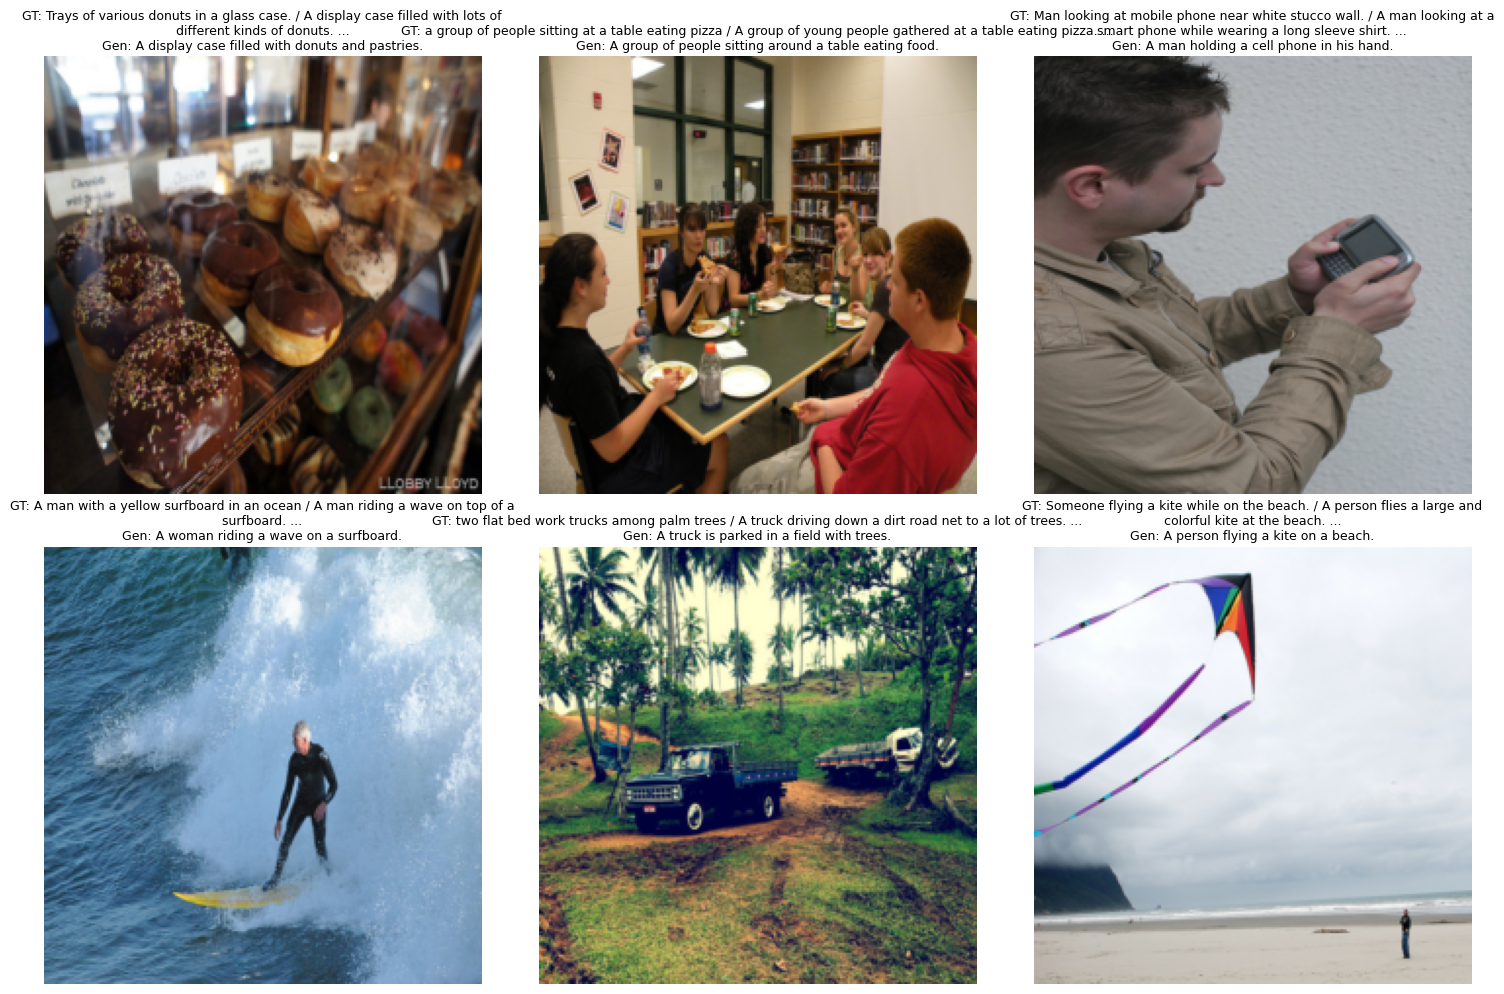

In [35]:
import matplotlib.pyplot as plt

@torch.no_grad()
def generate_caption(model, tokenizer, image_tensor, device, max_new_tokens=40):
    '''Greedy-decode a single caption for one preprocessed image tensor (C,H,W).'''
    model.eval()
    images = image_tensor.unsqueeze(0).to(device)
    visual_ctx = model.encode_image(images)  # (1, num_visual_tokens, C)

    bos_id = tokenizer.bos_token_id if tokenizer.bos_token_id is not None else tokenizer.eos_token_id
    eos_id = tokenizer.eos_token_id

    gen_ids = torch.full((1, 1), bos_id, dtype=torch.long, device=device)
    for _ in range(max_new_tokens):
        with torch.amp.autocast(device_type=device.type, dtype=torch.float16 if device.type == "cuda" else torch.float32):
            logits = model(gen_ids, visual_context=visual_ctx)
        next_tok = logits[:, -1, :].argmax(dim=-1, keepdim=True)
        gen_ids = torch.cat([gen_ids, next_tok], dim=1)
        if next_tok.item() == eos_id:
            break

    ids = gen_ids[0, 1:].tolist()
    if eos_id in ids:
        ids = ids[: ids.index(eos_id)]
    return tokenizer.decode(ids, skip_special_tokens=True)


# CLIP normalization stats (read from the same processor used to build clip_transform),
# NOT ImageNet stats -- V2's ViT used ImageNet mean/std, CLIP uses its own.
_clip_proc = CLIPImageProcessor.from_pretrained(CFG["clip_model_name"])
_CLIP_MEAN = torch.tensor(_clip_proc.image_mean).view(3, 1, 1)
_CLIP_STD = torch.tensor(_clip_proc.image_std).view(3, 1, 1)

def denormalize_for_display(img_tensor: torch.Tensor):
    img = img_tensor.detach().cpu() * _CLIP_STD + _CLIP_MEAN
    img = img.clamp(0, 1).permute(1, 2, 0).numpy()
    return img


# ---- Pick a few random samples from the held-out eval set ----
num_samples = 12
sample_indices = random.sample(range(len(eval_ds)), min(num_samples, len(eval_ds)))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, idx in zip(axes, sample_indices):
    sample = eval_ds[idx]
    img_tensor = sample["image"]
    gt_captions = sample["raw_captions"]  # up to 5 references

    generated = generate_caption(model, tokenizer, img_tensor, device)

    ax.imshow(denormalize_for_display(img_tensor))
    ax.axis("off")
    gt_display = " / ".join(gt_captions[:2]) + (" ..." if len(gt_captions) > 2 else "")
    ax.set_title(f"GT: {gt_display}\nGen: {generated}", fontsize=9, wrap=True)

plt.tight_layout()
plt.show()

In [37]:
# =====================================================================
# FINAL FULL EVALUATION -- entire 5k validation split
# (separate from the 1000-image holdout used for per-epoch eval during
# training; teacher-forced loss + greedy-decoded BLEU/METEOR, tqdm bar)
# =====================================================================
from tqdm.auto import tqdm as _tqdm

# 1) Load the full validation split. Adjust the split name below if your
#    HF dataset config names it differently (check with
#    `load_dataset(CFG["dataset_name"]).keys()` if this errors).
try:
    val_ds_raw = load_dataset(CFG["dataset_name"], split="validation")
except Exception:
    val_ds_raw = load_dataset(CFG["dataset_name"], split="val")

print(f"Full eval split: {len(val_ds_raw)} images, columns={val_ds_raw.column_names}")

val_row_idx_full = list(range(len(val_ds_raw)))
eval_ds_full = CocoMultiCapDataset(
    val_ds_raw, tokenizer, CFG["context_length"], val_row_idx_full,
    mode="eval", image_transform=clip_transform,
)
print(f"Evaluating on all {len(eval_ds_full)} images.")

eval_loader_full = DataLoader(
    eval_ds_full,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=_collate,
)

# 2) Run generation + scoring
model.eval()
tok = tokenizer
eos_id = tok.eos_token_id
bos_id = tok.bos_token_id if tok.bos_token_id is not None else tok.eos_token_id
ctx = CFG["context_length"]
amp_dtype = torch.float16 if CFG["amp_dtype"] == "fp16" else torch.float32

total_loss, n_batches = 0.0, 0
all_refs, all_hyps = [], []

with torch.no_grad():
    for batch in _tqdm(eval_loader_full, desc="Full eval (5k)", dynamic_ncols=True):
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        labels    = batch["labels"].to(device, non_blocking=True)
        images    = batch["images"].to(device, non_blocking=True)
        raw_caps  = batch.get("raw_captions", None)

        with torch.amp.autocast(device_type=device.type, dtype=amp_dtype):
            logits = model(input_ids, images=images)
            loss   = loss_fn(logits.view(-1, logits.size(-1)), labels.view(-1))
        if torch.isfinite(loss):
            total_loss += loss.item()
            n_batches  += 1

        visual_ctx = model.encode_image(images)
        B = images.size(0)
        gen_ids = torch.full((B, 1), bos_id, dtype=torch.long, device=device)
        for _ in range(min(ctx - 1, 60)):
            with torch.amp.autocast(device_type=device.type, dtype=amp_dtype):
                gen_logits = model(gen_ids, visual_context=visual_ctx)
            next_tok = gen_logits[:, -1, :].argmax(dim=-1, keepdim=True)
            gen_ids = torch.cat([gen_ids, next_tok], dim=1)
            if (next_tok == eos_id).all():
                break

        for b in range(B):
            ids_b = gen_ids[b, 1:].tolist()
            if eos_id in ids_b:
                ids_b = ids_b[:ids_b.index(eos_id)]
            hyp = tok.decode(ids_b, skip_special_tokens=True)
            all_hyps.append(hyp)
            if raw_caps is not None:
                all_refs.append(raw_caps[b])
            else:
                lbl = labels[b].tolist()
                ref_ids = [t for t in lbl if t != -100]
                all_refs.append([tok.decode(ref_ids, skip_special_tokens=True)])

model.train()

final_eval_loss = total_loss / max(n_batches, 1)
metrics = {"eval_loss": final_eval_loss}
if all_refs and all_hyps:
    metrics.update(_caption_evaluator.evaluate(all_refs, all_hyps))

print("=" * 64)
print(f"FULL VALIDATION RESULTS ({len(eval_ds_full)} images)")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")
print("=" * 64)

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

Full eval split: 5000 images, columns=['image', 'image_id', 'text', 'captions', 'split']
Evaluating on all 5000 images.


Full eval (5k):   0%|          | 0/157 [00:00<?, ?it/s]

FULL VALIDATION RESULTS (5000 images)
  eval_loss: 2.0513
  BLEU-1: 0.6975
  BLEU-2: 0.5052
  BLEU-3: 0.3448
  BLEU-4: 0.2362
  METEOR: 0.4597
